In [1]:
import lab as B
import torch
import matplotlib.pyplot as plt
import os
import numpy as np
import neuralprocesses.torch as nps
from photic.datasets import generate_mock_data
import wandb
import random

/Users/nmearl/miniforge3/envs/photic-dev/lib/python3.12/site-packages/fdm/fdm.py:38: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  coefs = mat.inv()[:, deriv] * np.math.factorial(deriv)
/Users/nmearl/miniforge3/envs/photic-dev/lib/python3.12/site-packages/fdm/fdm.py:44: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  / np.math.factorial(order)
/Users/nmearl/miniforge3/envs/photic-dev/lib/python3.12/site-packages/fdm/fdm.py:38: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  coefs = mat.inv()[:, deriv] * np.math.factorial(deriv)
/Users/nmearl/miniforge3/envs/photic-dev/lib/python3.12/site-packages/fdm/fdm.py:44: DeprecationWarning: `np.math` is a deprecated ali

In [2]:
device = torch.device('cpu')

if torch.cuda.is_available():
    print("Setting device to the gpu to `cuda`")
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    print("Setting device to the gpu to `mps`")
    device = torch.device("mps")

    # Required or else the we may run out of memory
    os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO'] = '0.0'

B.set_global_device(device)
torch.set_default_dtype(torch.float32)
B.set_random_seed(0)

LEARN_RATE = 3e-4
EPOCHS = int(1e6)

Setting device to the gpu to `mps`


In [3]:
# start a new wandb run to track this script
wandb.init(
    # set the wandb project where this run will be logged
    project="photic",

    # track hyperparameters and run metadata
    config={
    "learning_rate": LEARN_RATE,
    "architecture": "ConvCNP",
    "dataset": "TDE-MOCK",
    "epochs": EPOCHS,
    }
)

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: nmearl (photic). Use `wandb login --relogin` to force relogin
/Users/nmearl/miniforge3/envs/photic-dev/lib/python3.12/site-packages/wandb/sdk/lib/ipython.py:77: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import HTML, display  # type: ignore


/Users/nmearl/miniforge3/envs/photic-dev/lib/python3.12/site-packages/wandb/sdk/lib/ipython.py:77: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import HTML, display  # type: ignore


/Users/nmearl/miniforge3/envs/photic-dev/lib/python3.12/site-packages/wandb/sdk/lib/ipython.py:77: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import HTML, display  # type: ignore


/Users/nmearl/miniforge3/envs/photic-dev/lib/python3.12/site-packages/wandb/sdk/lib/ipython.py:77: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import HTML, display  # type: ignore


/Users/nmearl/miniforge3/envs/photic-dev/lib/python3.12/site-packages/wandb/sdk/lib/ipython.py:77: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import HTML, display  # type: ignore


In [4]:
# Construct a ConvCNP.
convcnp = nps.construct_convgnp(
    dim_x=1,
    dim_y=1,
    likelihood="het",
    # dim_lv=16,
    points_per_unit=1,
    dtype=torch.float32
)
convcnp = convcnp.to(device)

# Construct optimiser.
opt = torch.optim.Adam(convcnp.parameters(), LEARN_RATE)

for i in range(EPOCHS):
    # Sample a batch of new context and target sets. Replace this with your data. The
    # shapes are `(batch_size, dimensionality, num_data)`.
    x, y = generate_mock_data(amplitude_range=(0.9, 1.1),
                              x_break_range=(95, 105),
                              alpha_1_range=(-2.5, -1.5),
                              alpha_2_range=(1.5, 2.25),
                              delta_range=(0.09, 1.1),
                              batch_size=32, 
                              num_points=200, 
                              device=device)

    # For every batch, flip a coin. If heads, do you what you now do. If tails, 
    # choose a point on the x-axis. Every point smaller than that point becomes 
    # context, and every point bigger becomes target.
    if np.random.random() < 0.5:
        inds = np.random.permutation(x.shape[2])
        split = [np.random.randint(0, x.shape[2]), 35]
    else:
        inds = np.arange(x.shape[2])
        dem = np.random.randint(1, x.shape[2])
        split = [np.random.randint(0, dem), x.shape[2] - dem]

    xc, yc = x[:, :, inds[:split[0]]], y[:, :, inds[:split[0]]]
    xt, yt = x[:, :, inds[split[1]:]], y[:, :, inds[split[1]:]]

    # Compute the loss and update the model parameters.
    loss = -torch.mean(nps.loglik(convcnp, xc, yc, xt, yt, normalise=True, dtype_lik=torch.float32))
    
    wandb.log({"nctx": split[0], "ntrg": split[1], "loss": loss})

    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()

wandb.finish()

KeyboardInterrupt: 

In [5]:

wandb.finish()

/Users/nmearl/miniforge3/envs/photic-dev/lib/python3.12/site-packages/wandb/sdk/lib/ipython.py:77: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import HTML, display  # type: ignore


loss,█▇▆▇▇▅▆▄▃█▇▄█▄▇▃▂█▃█▇▇▂▁▁▂▇▇▃▂▇▂▅▅▂▂▁▂▃▇
nctx,▂▁▃▄▃▅▅▂▃▁▁▆▂▂▁▂▅▁▅▁▁▃▂▅▅▃▂▃▅▅▂▂▄▄▆▅▇█▂▂
ntrg,▂█▂▃▄▂▄▂▂▂█▂▄▂▆▂▂▂▃▇█▆▂▂▂▂▁▅▂▂▁▂▂▅▁▂▂▂▂▂
loss,-0.68555
nctx,12
ntrg,30


/Users/nmearl/miniforge3/envs/photic-dev/lib/python3.12/site-packages/wandb/sdk/lib/ipython.py:77: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import HTML, display  # type: ignore


/Users/nmearl/miniforge3/envs/photic-dev/lib/python3.12/site-packages/wandb/sdk/lib/ipython.py:77: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import HTML, display  # type: ignore


In [ ]:
# Make predictions on some new data
pxt, pyt = generate_mock_data(amplitude_range=(0.9, 1.1),
                              x_break_range=(95, 105),
                              alpha_1_range=(-2.5, -1.5),
                              alpha_2_range=(1.5, 2.25),
                              delta_range=(0.09, 1.1),
                              batch_size=1, num_points=100, device=device)

In [54]:
# Use batch to create random set of context points
maxctx = 100
inds = np.random.permutation(pxt.shape[2])
pxc, pyc = pxt[:1, :, inds[:maxctx]], pyt[:1, :, inds[:maxctx]]
pxc, pyc = pxt[:1, :, :maxctx], pyt[:1, :, :maxctx]

# Running without moving back to the cpu, or simply using `ar_predict` either crashes
# the system or runs out of memory...
# with B.on_device('cpu'):
#     mean, var, noiseless_samples, noisy_samples = nps.predict(convcnp.cpu(), pxc.cpu(), pyc.cpu(), pxt.cpu())
with torch.no_grad():
    mean, var, noiseless_samples, noisy_samples = nps.ar_predict(convcnp, pxc, pyc, pxt)

# mean, var, noiseless_samples, noisy_samples = nps.ar_predict(convcnp, pxc, pyc, pxt)

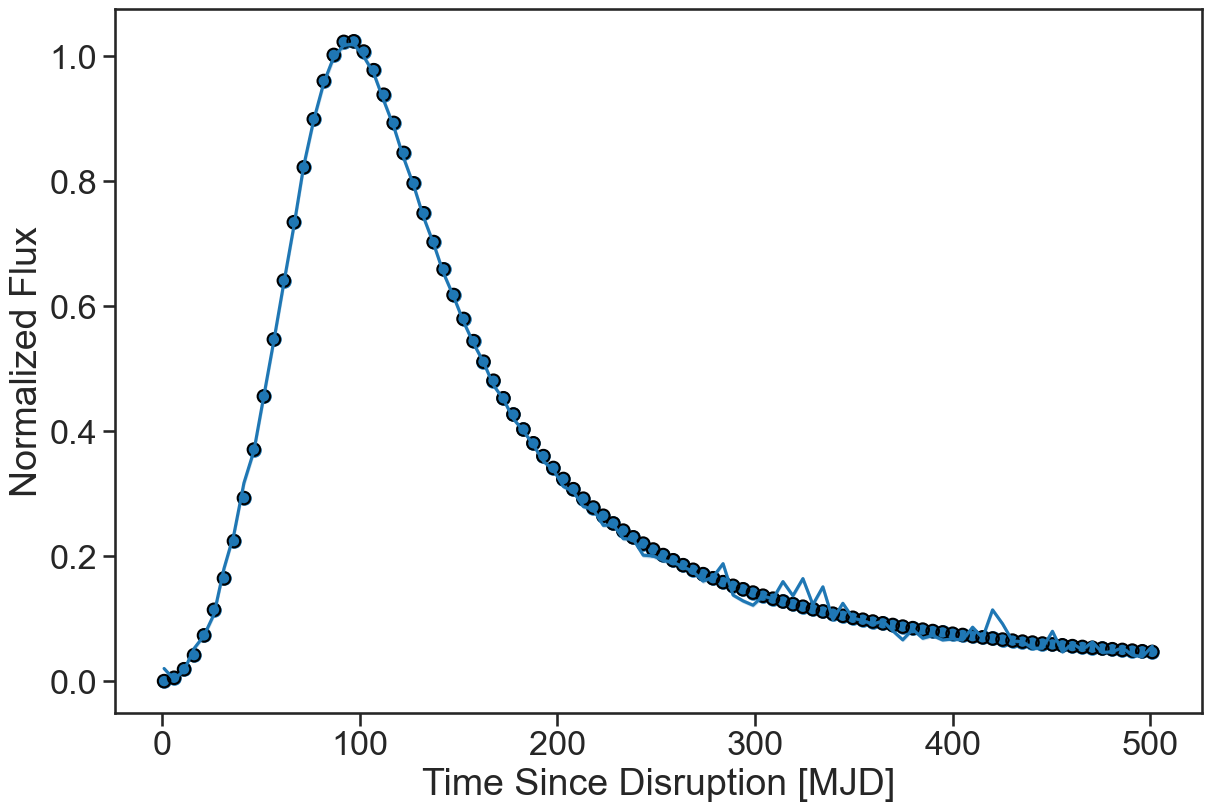

In [52]:
import seaborn as sns

sns.set_style("ticks")
sns.set_context("talk", font_scale=1.5)

f, ax = plt.subplots(figsize=(12, 8), layout='constrained')

for i in range(1):
    ctx_x, ctx_y = pxc.cpu().numpy()[i, 0, :], pyc.cpu().numpy()[i, 0, :]
    tar_x, tar_y = pxt.cpu().numpy()[i, 0, :], pyt.cpu().numpy()[i, 0, :]

    ax.scatter(ctx_x, ctx_y)
    ax.scatter(tar_x, tar_y, color="none", edgecolor="k")

for i in range(1):
    pre_x, pre_y = pxt.cpu().numpy()[i, 0, :], mean.detach().cpu().numpy()[i, 0, :]
    pre_yerr = np.sqrt(var.detach().cpu().numpy()[i, 0, :])
    
    ax.plot(pre_x, pre_y)
    ax.fill_between(pre_x, pre_y - pre_yerr, pre_y + pre_yerr, alpha=0.25, color="C0")

ax.set_ylabel("Normalized Flux")
ax.set_xlabel("Time Since Disruption [MJD]")

f.savefig(f"/Users/nmearl/Downloads/convcnp_mock_{maxctx}.png")

In [55]:
from pathlib import Path
import pickle

with open(Path(".") / "model.pkl", 'wb') as f:
    pickle.dump(convcnp, f)

TypeError: cannot pickle 'module' object